In [54]:
import numpy as np
import pandas as pd
import os

from sklearn.metrics import roc_curve, roc_auc_score
import pickle

In [3]:
os.getcwd()

'c:\\Users\\k\\Credit_Risk_Model\\modeling'

In [4]:
os.chdir('..')

In [5]:
os.getcwd()

'c:\\Users\\k\\Credit_Risk_Model'

## loading test datasets

In [7]:
# model testing dataset
loan_data_inputs_test = pd.read_csv('data/inputs_test.csv')
loan_data_targets_test = pd.read_csv('data/target_test.csv')

## Selecting features

In [8]:
input_test_with_ref_cat = loan_data_inputs_test.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>86',
]]

In [9]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [10]:
inputs_test = input_test_with_ref_cat.drop(ref_categories, axis=1)
inputs_test.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
0,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
1,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,1,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
3,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
4,1,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0


In [12]:
inputs_test.shape

(93257, 84)

## Loading trained Logistic Regression Model

In [18]:
from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_PValues:
    
    def __init__(self, *args, **kwargs):
        self.model = linear_model.LogisticRegression(*args, **kwargs)

    def fit(self, X, y):
        self.model.fit(X, y)
        
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom, (X.shape[1], 1)).T
        F_ij = np.dot((X / denom).T, X)
        Cramer_Rao = np.linalg.inv(F_ij)
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores]
        
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [19]:
lg_model = pickle.load(open('trained_models/Logistic_Regression_model_with_p_values', 'rb'))

### Predicting probabilities for the test data

In [22]:
test_data_predictions = lg_model.model.predict_proba(inputs_test)

column 0 → probability of class 0 = bad borrower                                                                                                                         
column 1 → probability of class 1 = good borrower

In [33]:
df_predictions  = pd.DataFrame(test_data_predictions)

df_predictions.head()

,0,1
0,0.075787,0.924213
1,0.149216,0.850784
2,0.114852,0.885148
3,0.061278,0.938722
4,0.031425,0.968575


In [35]:
# Keeps only the predicted probability of class 1, meaning the probability of being a good borrower.
prob_of_good_borrower = test_data_predictions[:, 1]
prob_of_good_borrower

array([0.92421297, 0.85078394, 0.88514831, ..., 0.97308965, 0.95977402,
       0.9520687 ], shape=(93257,))

In [36]:
actual_values = loan_data_targets_test.reset_index(drop=True)
actual_values.shape

(93257, 1)

In [37]:
actual_vs_predicted_values = pd.concat([actual_values, pd.DataFrame(prob_of_good_borrower)], axis=1)
actual_vs_predicted_values

,good_bad,0
0,1,0.924213
1,1,0.850784
2,1,0.885148
3,1,0.938722
4,1,0.968575
...,...,...
93252,1,0.880192
93253,1,0.966136
93254,0,0.973090
93255,1,0.959774


In [38]:
actual_vs_predicted_values.shape

(93257, 2)

In [39]:
actual_vs_predicted_values.columns = ['loan_data_targets_test', 'predicted_prob_being_good_borrower']

In [41]:
actual_vs_predicted_values.head()

,loan_data_targets_test,predicted_prob_being_good_borrower
0,1,0.924213
1,1,0.850784
2,1,0.885148
3,1,0.938722
4,1,0.968575


In [42]:
actual_vs_predicted_values.index = loan_data_inputs_test.index

In [44]:
actual_vs_predicted_values.head()

,loan_data_targets_test,predicted_prob_being_good_borrower
0,1,0.924213
1,1,0.850784
2,1,0.885148
3,1,0.938722
4,1,0.968575


In [51]:
threshold = 0.9

actual_vs_predicted_values['y_hat_test'] = np.where(
    actual_vs_predicted_values['predicted_prob_being_good_borrower'] > threshold,
    1,
    0
)

actual_vs_predicted_values.head()

,loan_data_targets_test,predicted_prob_being_good_borrower,y_hat_test
0,1,0.924213,1
1,1,0.850784,0
2,1,0.885148,0
3,1,0.938722,1
4,1,0.968575,1


In [52]:
pd.crosstab(
    actual_vs_predicted_values['loan_data_targets_test'],
    actual_vs_predicted_values['y_hat_test'],
    rownames=['Actual'],
    colnames=['Predicted']
)

Predicted,0,1
Actual,,
0,7382,2808
1,35816,47251


In [53]:
pd.crosstab(
    actual_vs_predicted_values['loan_data_targets_test'],
    actual_vs_predicted_values['y_hat_test'],
    rownames=['Actual'],
    colnames=['Predicted']
) / actual_vs_predicted_values.shape[0]

Predicted,0,1
Actual,,
0,0.079158,0.030110
1,0.384057,0.506675


### roc_curve 
ROC curve shows model performance at many different thresholds

In [62]:
fpr, tpr, thresholds = roc_curve(
    actual_vs_predicted_values['loan_data_targets_test'], 
    actual_vs_predicted_values['predicted_prob_being_good_borrower']
)

Text(0.5, 1.0, 'Roc curve')

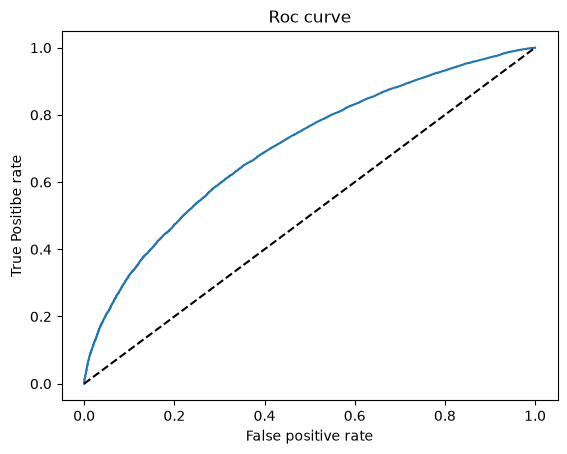

In [63]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle='--', color='k')
plt.xlabel("False positive rate")
plt.ylabel("True Positibe rate")
plt.title('Roc curve')

### row_auc_score
gives one number showing how well the model separates good and bad borrowers.

In [64]:
AUC_score = roc_auc_score(
    actual_vs_predicted_values['loan_data_targets_test'],
    actual_vs_predicted_values['y_hat_test']
)
AUC_score

0.6466328509567214

### Gini metric
Gini tells us how powerful the model is at ranking risky and safe customers.

In [66]:
actual_vs_predicted_values = actual_vs_predicted_values.sort_values('predicted_prob_being_good_borrower')
actual_vs_predicted_values.head()

,loan_data_targets_test,predicted_prob_being_good_borrower,y_hat_test
64110,0,0.494492,0
50505,1,0.495115,0
81256,1,0.500303,0
2051,0,0.505694,0
64010,0,0.507822,0


In [67]:
actual_vs_predicted_values = actual_vs_predicted_values.reset_index()
actual_vs_predicted_values.head()

,index,loan_data_targets_test,predicted_prob_being_good_borrower,y_hat_test
0,64110,0,0.494492,0
1,50505,1,0.495115,0
2,81256,1,0.500303,0
3,2051,0,0.505694,0
4,64010,0,0.507822,0


### cumulative gains / KS table.

In [74]:
actual_vs_predicted_values['Cumulative N Population'] = actual_vs_predicted_values.index + 1

actual_vs_predicted_values['Cumulative N Good Borrowers'] = (
    actual_vs_predicted_values['loan_data_targets_test'].cumsum()
)

actual_vs_predicted_values['Cumulative N Bad Borrowers'] = (
    actual_vs_predicted_values['Cumulative N Population']
    - actual_vs_predicted_values['Cumulative N Good Borrowers']
)

In [75]:
actual_vs_predicted_values.head()

,index,loan_data_targets_test,predicted_prob_being_good_borrower,y_hat_test,Cumulative N Population,Cumulative N Good Borrowers,Cumulative N bad Borrowers,Cumulative N Bad Borrowers
0,64110,0,0.494492,0,1,0,0,1
1,50505,1,0.495115,0,2,1,0,1
2,81256,1,0.500303,0,3,2,0,1
3,2051,0,0.505694,0,4,2,0,2
4,64010,0,0.507822,0,5,2,0,3


In [77]:
actual_vs_predicted_values['Cumulative Perc Population'] = (
    actual_vs_predicted_values['Cumulative N Population']
    / actual_vs_predicted_values.shape[0]
)

actual_vs_predicted_values['Cumulative Perc Good Borrowers'] = (
    actual_vs_predicted_values['Cumulative N Good Borrowers']
    / actual_vs_predicted_values['loan_data_targets_test'].sum()
)

actual_vs_predicted_values['Cumulative Perc Bad Borrowers'] = (
    actual_vs_predicted_values['Cumulative N Bad Borrowers']
    / (
        actual_vs_predicted_values.shape[0]
        - actual_vs_predicted_values['loan_data_targets_test'].sum()
    )
)

In [78]:
actual_vs_predicted_values.head()

,index,loan_data_targets_test,predicted_prob_being_good_borrower,y_hat_test,Cumulative N Population,Cumulative N Good Borrowers,Cumulative N bad Borrowers,Cumulative N Bad Borrowers,Cumulative Perc Population,Cumulative Perc Good Borrowers,Cumulative Perc Bad Borrowers
0,64110,0,0.494492,0,1,0,0,1,0.000011,0.000000,0.000098
1,50505,1,0.495115,0,2,1,0,1,0.000021,0.000012,0.000098
2,81256,1,0.500303,0,3,2,0,1,0.000032,0.000024,0.000098
3,2051,0,0.505694,0,4,2,0,2,0.000043,0.000024,0.000196
4,64010,0,0.507822,0,5,2,0,3,0.000054,0.000024,0.000294


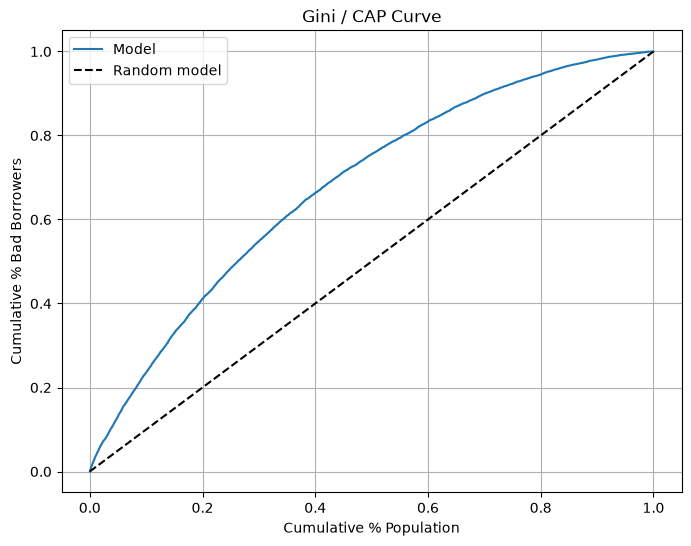

In [81]:
plt.figure(figsize=(8, 6))

plt.plot(
    actual_vs_predicted_values['Cumulative Perc Population'],
    actual_vs_predicted_values['Cumulative Perc Bad Borrowers'],
    label='Model'
)

plt.plot(
    actual_vs_predicted_values['Cumulative Perc Population'],
    actual_vs_predicted_values['Cumulative Perc Population'],
    linestyle='--',
    color='k',
    label='Random model'
)

plt.xlabel("Cumulative % Population")
plt.ylabel("Cumulative % Bad Borrowers")
plt.title("Gini / CAP Curve")
plt.legend()
plt.grid(True)
plt.show()

In [82]:
Gini = AUC_score * 2 - 1
Gini

0.2932657019134428

### Kolmogorov-Smirnov statistic 
KS tells us the maximum distance between cumulative good borrowers and cumulative bad borrowers.

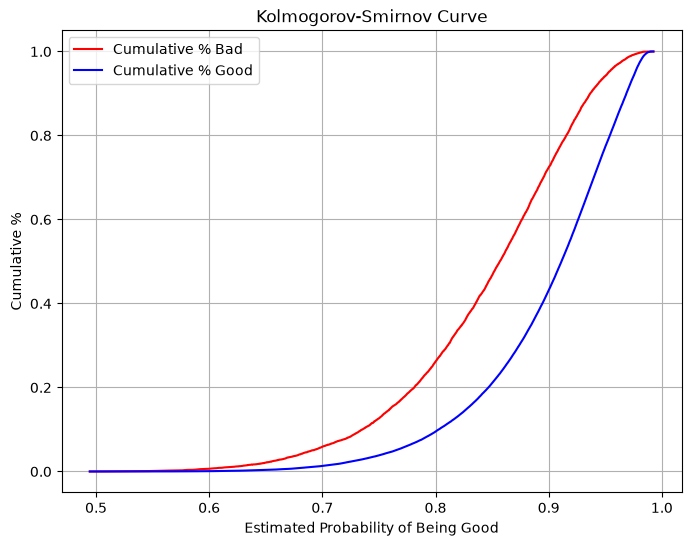

In [86]:
plt.figure(figsize=(8, 6))

plt.plot(
    actual_vs_predicted_values['predicted_prob_being_good_borrower'],
    actual_vs_predicted_values['Cumulative Perc Bad Borrowers'],
    color='r',
    label='Cumulative % Bad'
)

plt.plot(
    actual_vs_predicted_values['predicted_prob_being_good_borrower'],
    actual_vs_predicted_values['Cumulative Perc Good Borrowers'],
    color='b',
    label='Cumulative % Good'
)

plt.xlabel('Estimated Probability of Being Good')
plt.ylabel('Cumulative %')
plt.title('Kolmogorov-Smirnov Curve')
plt.legend()
plt.grid(True)
plt.show()

In [88]:
KS = max(actual_vs_predicted_values['Cumulative Perc Bad Borrowers'] - actual_vs_predicted_values['Cumulative Perc Good Borrowers'])
KS

0.2968539589918978